#Assignment 1

Max collaborators = 2

In [ ]:
COLLABORATORS_NAME = "Argha Das, Rohan Bahorder"
COLLABORATORS_ID = " 24341220 , 24141137 "

# **Part 1 [15 Marks]**

In this part, you will work with point processing, HE, AHE, and CLAHE.

In [3]:
import numpy as np
from skimage import io, color, exposure
import matplotlib.pyplot as plt
### If you need other dependencies import here -
import cv2
### Code ends

In [38]:
### If you need helper functions defined, define here -

### Code ends

## Task 1 - Basic Image Operation

Import any photograph taken by you (RGB) (`sample_1.jpeg`/`sample_1.jpg`) as a numpy array, save it in the variable `I`.

A picture taken from your phone of any scenary/streets/building is better.

Remember - your image name MUST be `sample_1.jpeg`/`sample_1.jpg`.

Make sure the height and the width of the image is **smaller than 1000 pixels**.

In [4]:
I= io.imread('sample_1.jpg') # Replace None with appropriate import function call


# find the height and the width of the image
H =  I.shape[0] # should contain height
W = I.shape[1] # should contain width
print("Height is", H)
print("Width is", W)

Height is 600
Width is 450


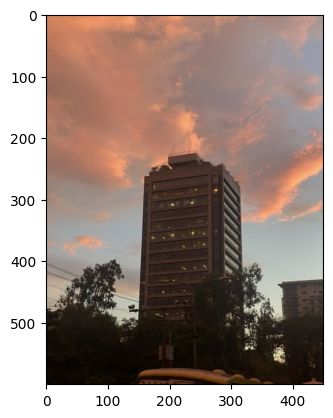

In [22]:
I = I = io.imread('sample_1.jpg') / 255.0 # Replace none and normalize the image so that the pixel values of each channel are between 0 and 1

### Write a code to display the image -
plt.imshow(I)
plt.show()
### Code ends

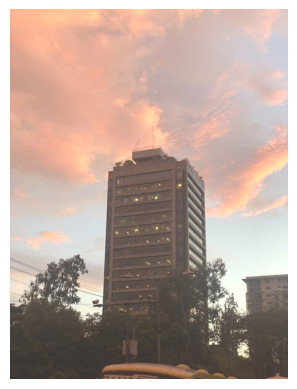

In [32]:
# Increase the brightness of the image without changing the contrast.
# Save the resulting image in I_bright.
I_bright = np.clip(I + 0.2, 0, 1)

### Write a code to display the I_bright -
plt.imshow(I_bright)
plt.axis('off')
plt.show()
### Code ends

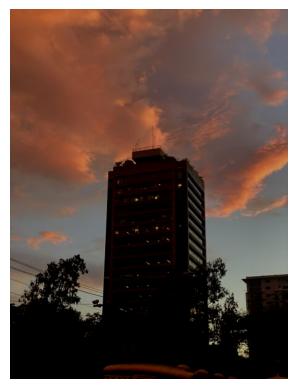

In [31]:
# Decrease the brightness of the image without changing the contrast.
# Save the resulting image in I_dark.
I_dark = np.clip(I - 0.2, 0, 1)

### Write a code to display the I_dark -
plt.imshow(I_dark)
plt.axis('off')
plt.show()
### Code ends

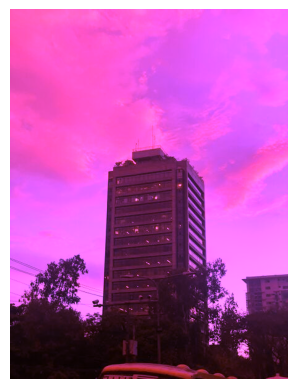

In [30]:
# Multiply the three channels of image I with three DIFFERENT numbers between 0.3 and 3
# Save the resulting image in I_tint and display it.
# The resulting image should have some color shift
I_tint = np.zeros(I.shape)

# HINT:
# I_tint = np.zeros(I.shape)
# I_tint[:, :, 0] =  ..... I[:, :, 0].....
# ......
I_tint[:, :, 0] = np.clip(I[:, :, 0] * 1.5, 0, 1)   # Red channel
I_tint[:, :, 1] = np.clip(I[:, :, 1] * 0.7, 0, 1)   # Green channel
I_tint[:, :, 2] = np.clip(I[:, :, 2] * 2.0, 0, 1)   # Blue channel

### Write a code to display the I_tint -
plt.imshow(I_tint)
plt.axis('off')
plt.show()
### Code ends

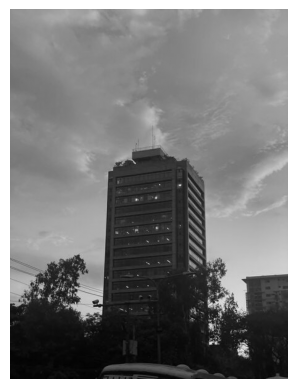

In [29]:
# Convert the image into a grayscale image.
# Save it to I_gray and display it
I_gray = color.rgb2gray(I)
### Write a code to display the I_gray -
plt.imshow(I_gray, cmap='gray')
plt.axis('off')
plt.show()
### Code ends

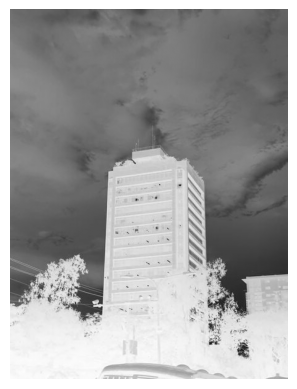

In [28]:
# Display the negative of the grayscale image
I_neg = 1 - I_gray

### Write a code to display the I_neg -
plt.imshow(I_neg, cmap='gray')
plt.axis('off')
plt.show()
### Code ends

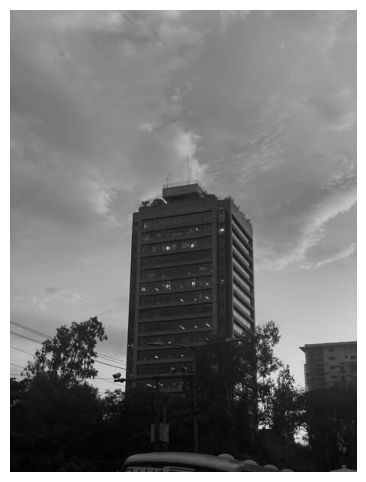

In [30]:
# Artificially degrade the **grayscale image** by reducing it contrast
# You can do so by recaling the gray values and concentrating them in a narrow range,
# say between 0.3 and 0.6.
# Save the image as I_degraded and display it
# HINT: SEE lab-3-codes

I_degraded = 0.3 + 0.3 * I_gray   # (upper - lower = 0.3)

### BEGIN SOLUTION
plt.imshow(I_degraded, cmap='gray')
plt.axis('off')
plt.show()
### END SOLUTION

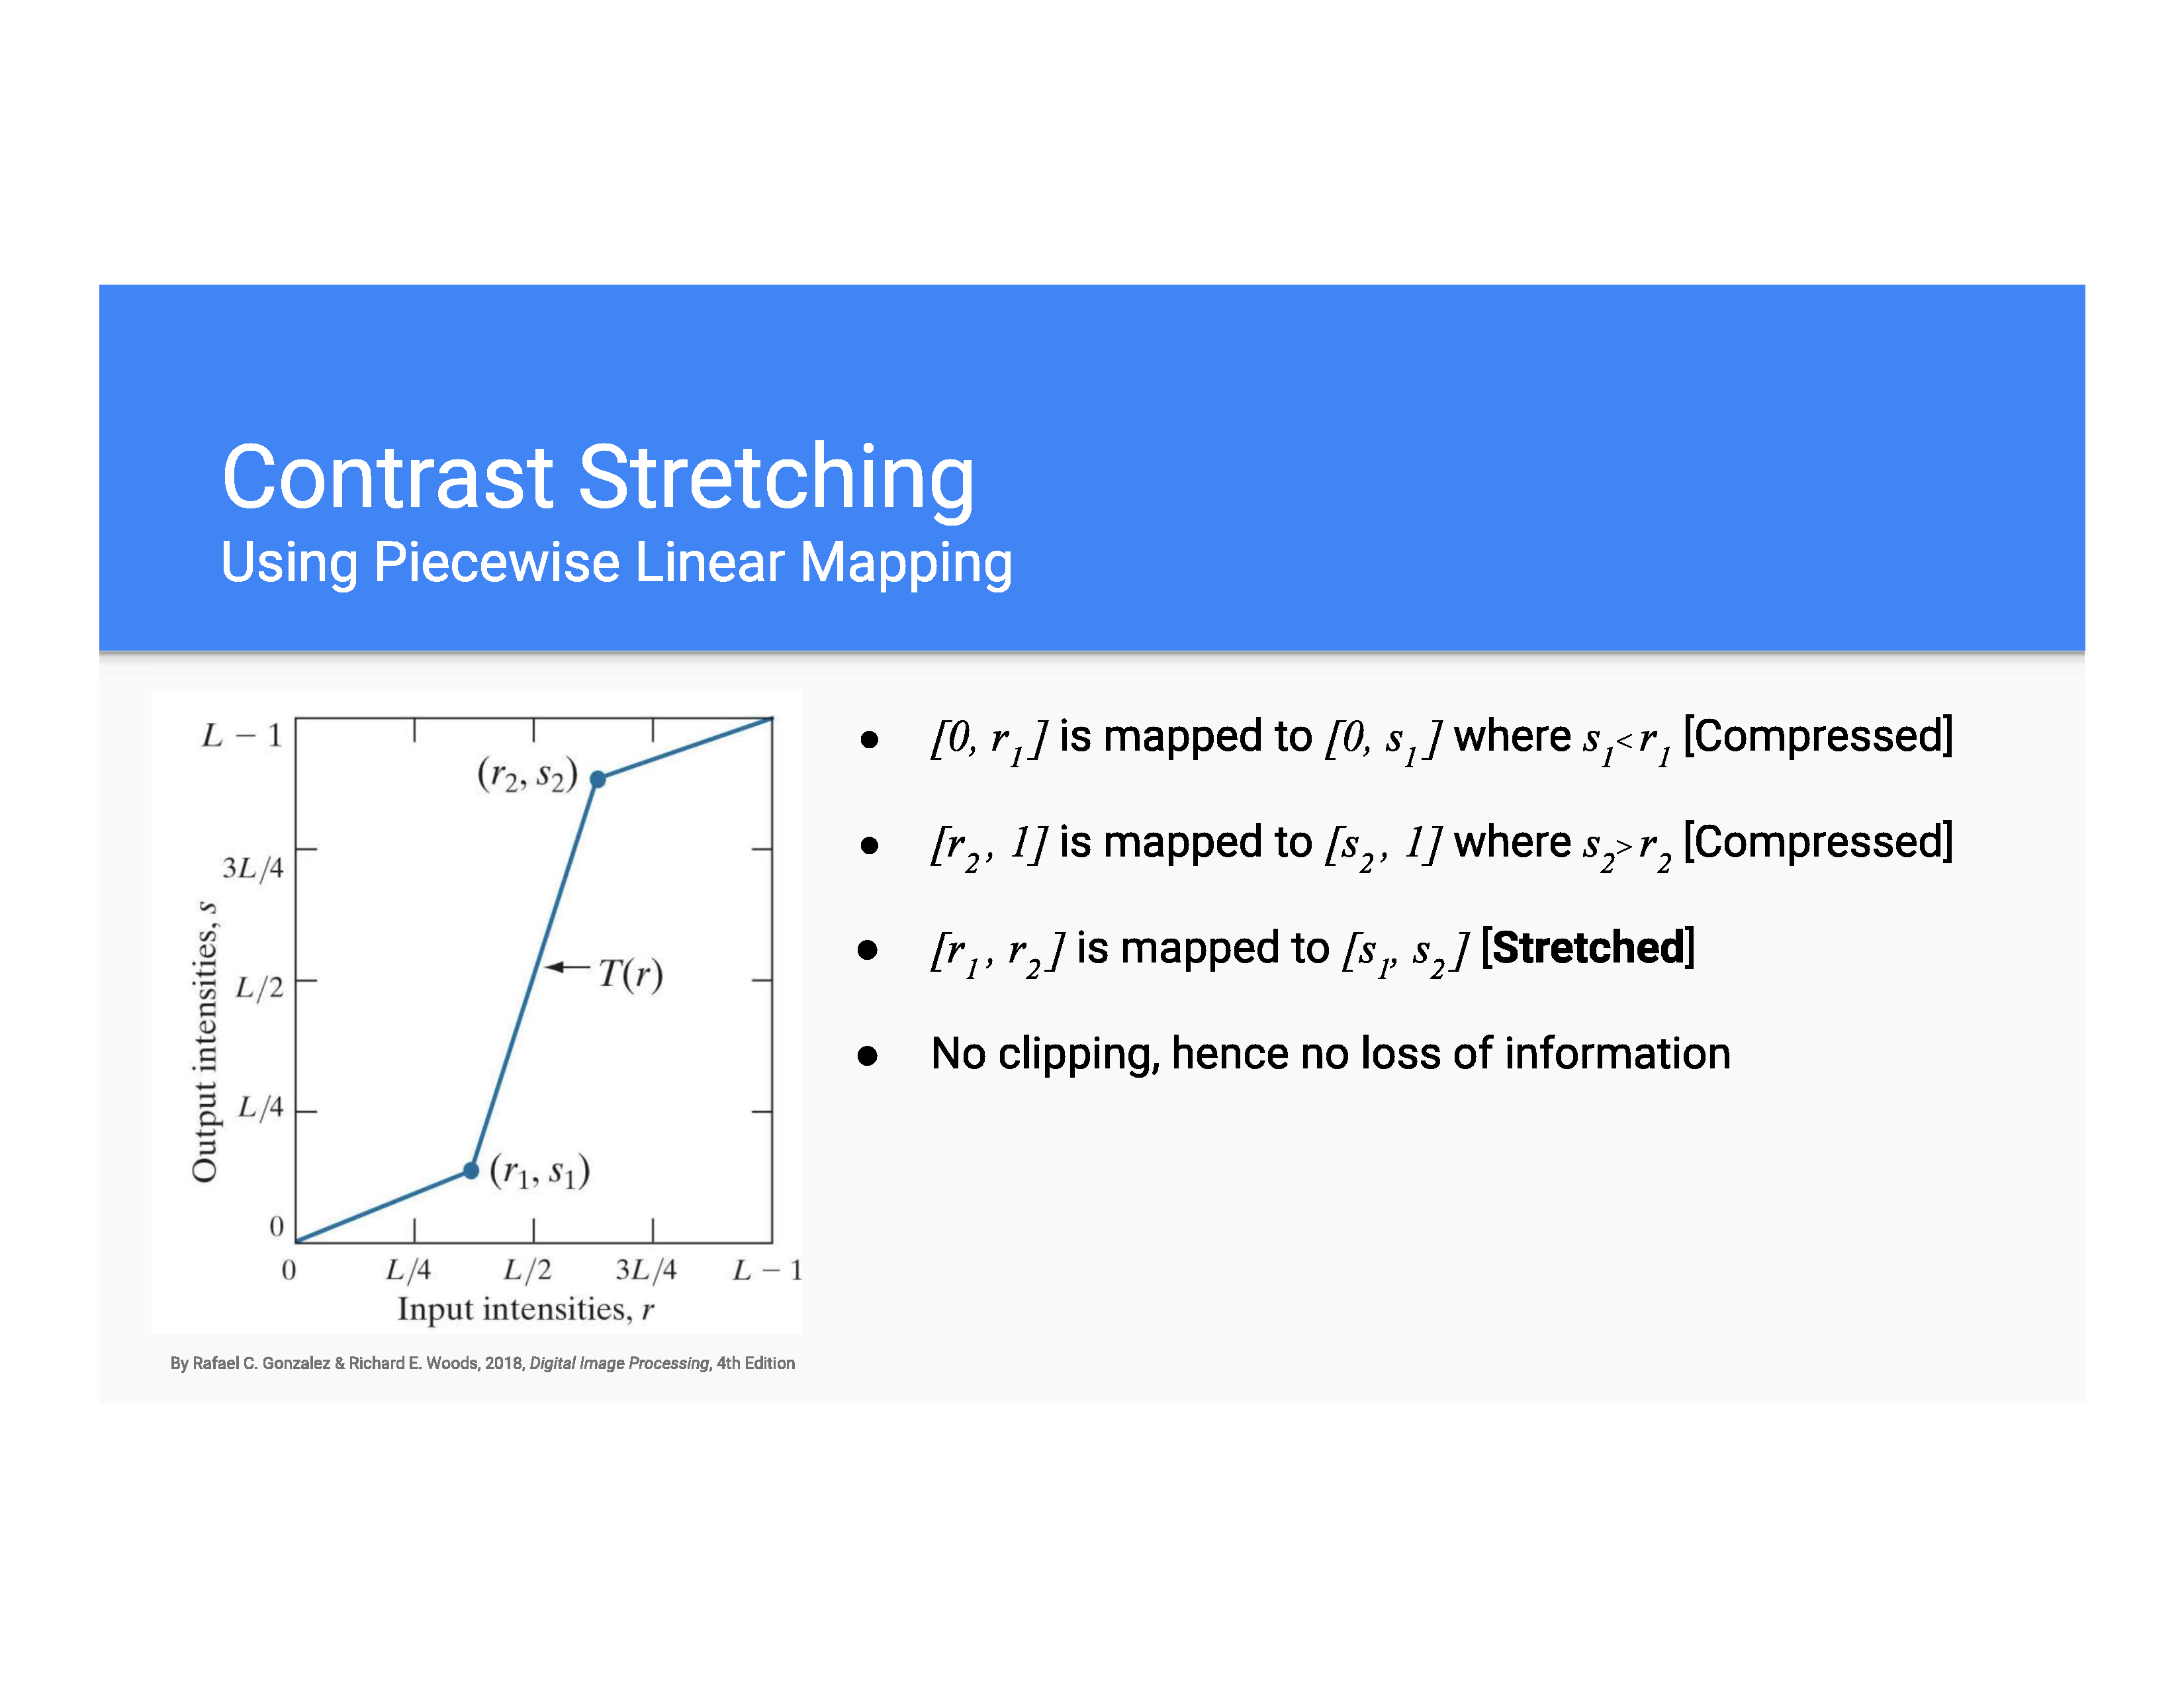

In [31]:
# Complete the following function to perform Piecewise Linear Contrast stretching
# That is, implement the map shown in the picture above

# Assume both input and output images are normalized between 0 and 1

def piecewise_contrast_stretch(I, r1, r2, s1, s2):
    I_stretched = np.zeros_like(I)

    # Region 1: [0, r1]
    mask1 = I < r1
    I_stretched[mask1] = (s1 / r1) * I[mask1]

    # Region 2: [r1, r2]
    mask2 = (I >= r1) & (I < r2)
    I_stretched[mask2] = s1 + ((s2 - s1) / (r2 - r1)) * (I[mask2] - r1)

    # Region 3: [r2, 1]
    mask3 = I >= r2
    I_stretched[mask3] = s2 + ((1 - s2) / (1 - r2)) * (I[mask3] - r2)

    return np.clip(I_stretched, 0, 1)


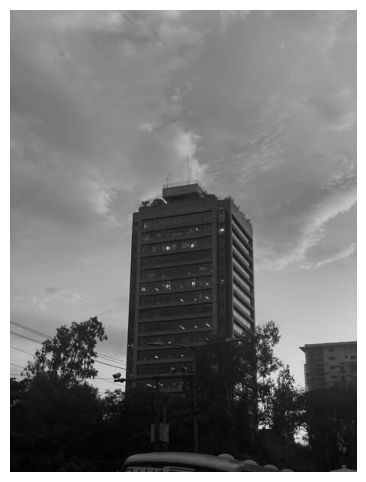

In [32]:
# To test your implementation, contrast stretch the degraded image I_degraded to fix it
r1 = 0.3
r2 = 0.6
s1 = 0.1
s2 = 0.9

I_stretched = piecewise_contrast_stretch(I_degraded, r1, r2, s1, s2)

### Write a code to display the I_stretched -
plt.imshow(I_stretched, cmap='gray')
plt.axis('off')
plt.show()
### Code ends


## Task 2 - Histogram and Equalization

/tmp/ipython-input-2285355555.py:27: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I)


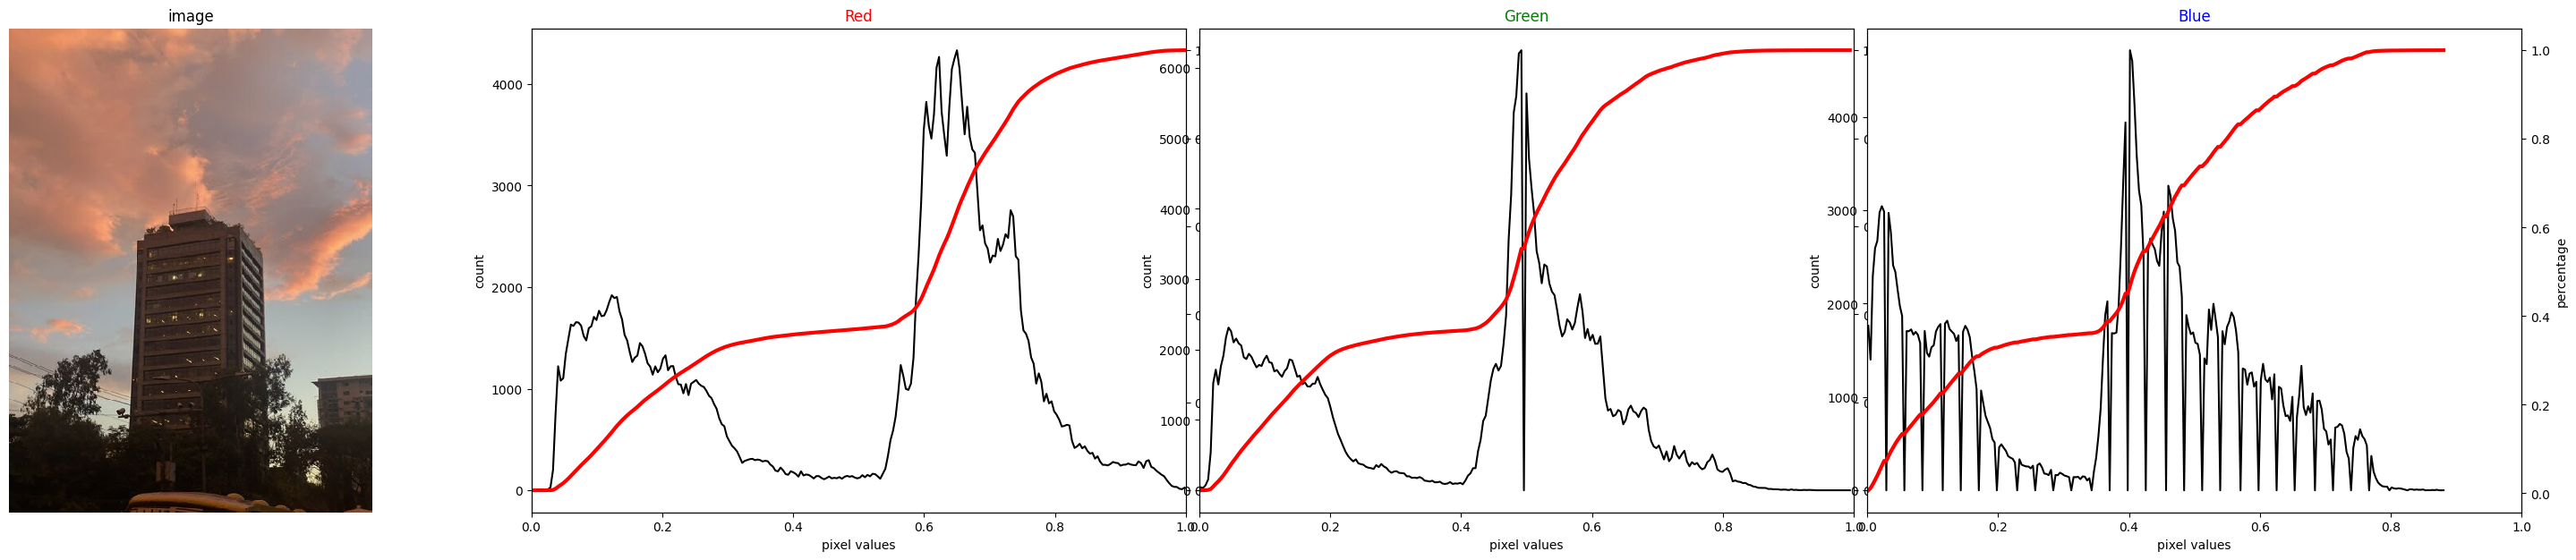

In [44]:
# Plot the image and its histogram + cdf of the original image I
# Note that it is a color image, so it will have three different histograms

### Begin solution

def plot_hist(I, nbins=256, normalize=False, plot_cdf=True):

    hist, bins_hist = exposure.histogram(I.ravel(), nbins=nbins, normalize=normalize)
    plt.plot(bins_hist, hist, 'k')
    plt.xlabel("pixel values")
    if normalize:
        plt.ylabel("probability")
    else:
        plt.ylabel("count")
    xmax = 1 if I.max() <= 1 else 255
    plt.xlim([0, xmax])

    if plot_cdf:
        cdf, bins_cdf = exposure.cumulative_distribution(I.ravel(), nbins=nbins)
        plt.twinx()
        plt.plot(bins_cdf, cdf, 'r', lw=3)
        plt.ylabel("percentage")


plt.rcParams['figure.figsize'] = (30,6)
plt.subplot(1,4, 1)
io.imshow(I)
plt.axis("off")
plt.title("image")
plt.subplot(1, 4, 2)
plot_hist(I[:, :, 0], plot_cdf=True)
plt.title("Red", color="red")

plt.subplot(1, 4, 3)
plot_hist(I[:, :, 1], plot_cdf=True)
plt.title("Green", color="green")

plt.subplot(1, 4, 4)
plot_hist(I[:, :, 2], plot_cdf=True)
plt.title("Blue", color="blue")

plt.show()
### End solution

/tmp/ipython-input-1893510290.py:7: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I)


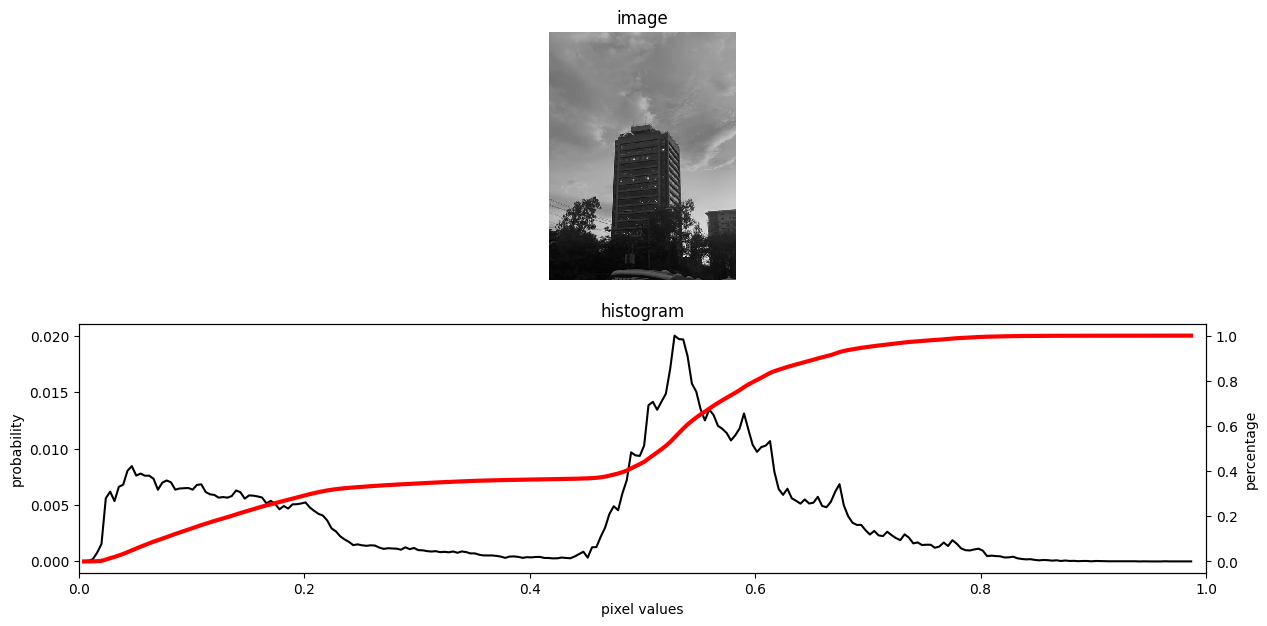

In [48]:
# Plot the grayscale image, I_gray, and its histogram + cdf

### Begin solution
def plot_img_and_hist(I, nbins=256, normalize=False, plot_cdf=True, figsize=(12, 6)):
    fig, ax = plt.subplots(2, 1, figsize=figsize)
    plt.subplot(2, 1, 1)
    io.imshow(I)
    plt.axis("off")
    plt.title("image")

    plt.subplot(2, 1, 2)
    plot_hist(I_gray, nbins=nbins, normalize=normalize, plot_cdf=plot_cdf)
    plt.title("histogram")
plt.rcParams['figure.figsize'] = (6, 6)
plot_img_and_hist(I_gray, normalize=True)
plt.show()
### End solution

/tmp/ipython-input-3863254695.py:7: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I)


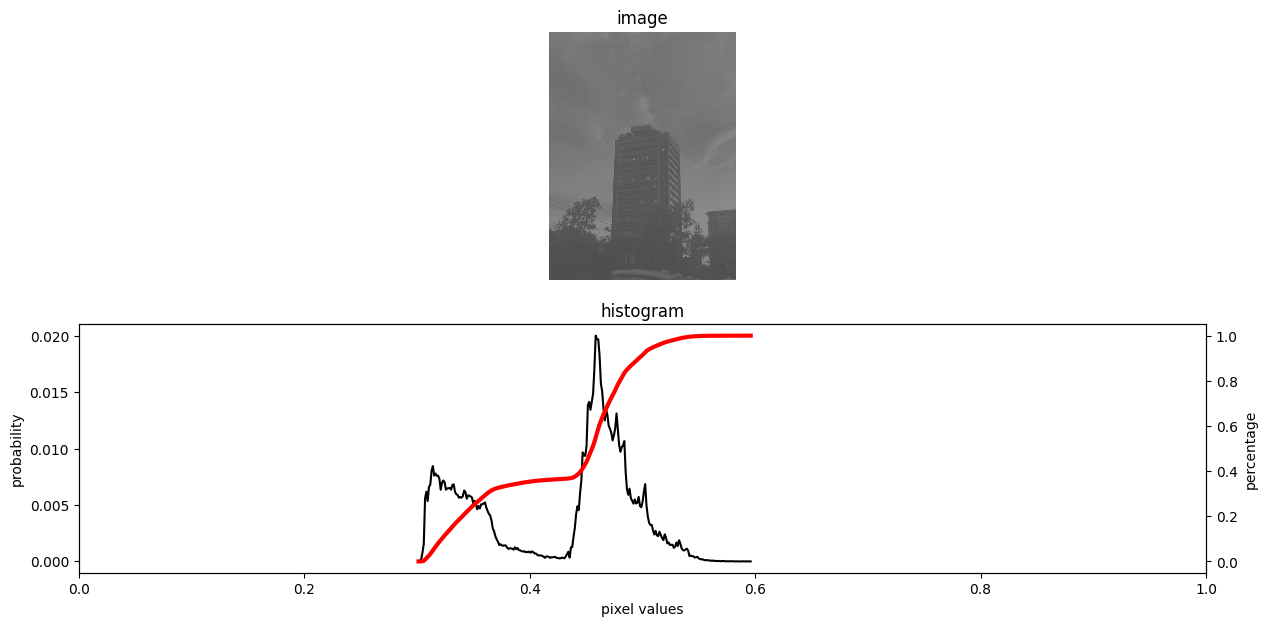

In [49]:
# Plot the degraded image, I_degraded, and its histogram + cdf

### Begin solution
def plot_img_and_hist(I, nbins=256, normalize=False, plot_cdf=True, figsize=(12, 6)):
    fig, ax = plt.subplots(2, 1, figsize=figsize)
    plt.subplot(2, 1, 1)
    io.imshow(I)
    plt.axis("off")
    plt.title("image")

    plt.subplot(2, 1, 2)
    plot_hist(I_degraded, nbins=nbins, normalize=normalize, plot_cdf=plot_cdf)
    plt.title("histogram")
plt.rcParams['figure.figsize'] = (6, 6)
plot_img_and_hist(I_degraded, normalize=True)
plt.show()
### End solution

/tmp/ipython-input-3481416770.py:10: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I)


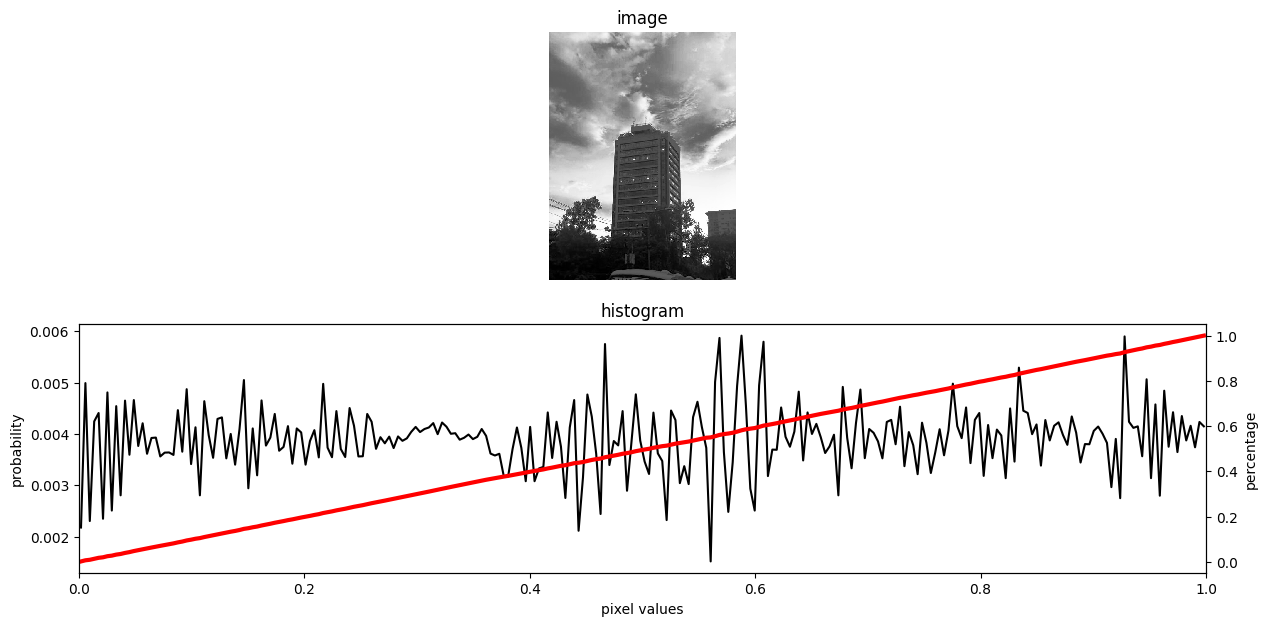

In [50]:
# Equalize the histogram of the degraded image I_degraded
# Save the result in I_recon_gray
I_recon_gray = exposure.equalize_hist(I_degraded)

### Write a code to display the I_recon_gray along with its histogram + CDF -

def plot_img_and_hist(I, nbins=256, normalize=False, plot_cdf=True, figsize=(12, 6)):
    fig, ax = plt.subplots(2, 1, figsize=figsize)
    plt.subplot(2, 1, 1)
    io.imshow(I)
    plt.axis("off")
    plt.title("image")

    plt.subplot(2, 1, 2)
    plot_hist(I_recon_gray, nbins=nbins, normalize=normalize, plot_cdf=plot_cdf)
    plt.title("histogram")

plt.rcParams['figure.figsize'] = (6, 6)
plot_img_and_hist(I_recon_gray, normalize=True)
plt.show()
### Code ends

/tmp/ipython-input-4018446255.py:10: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I)


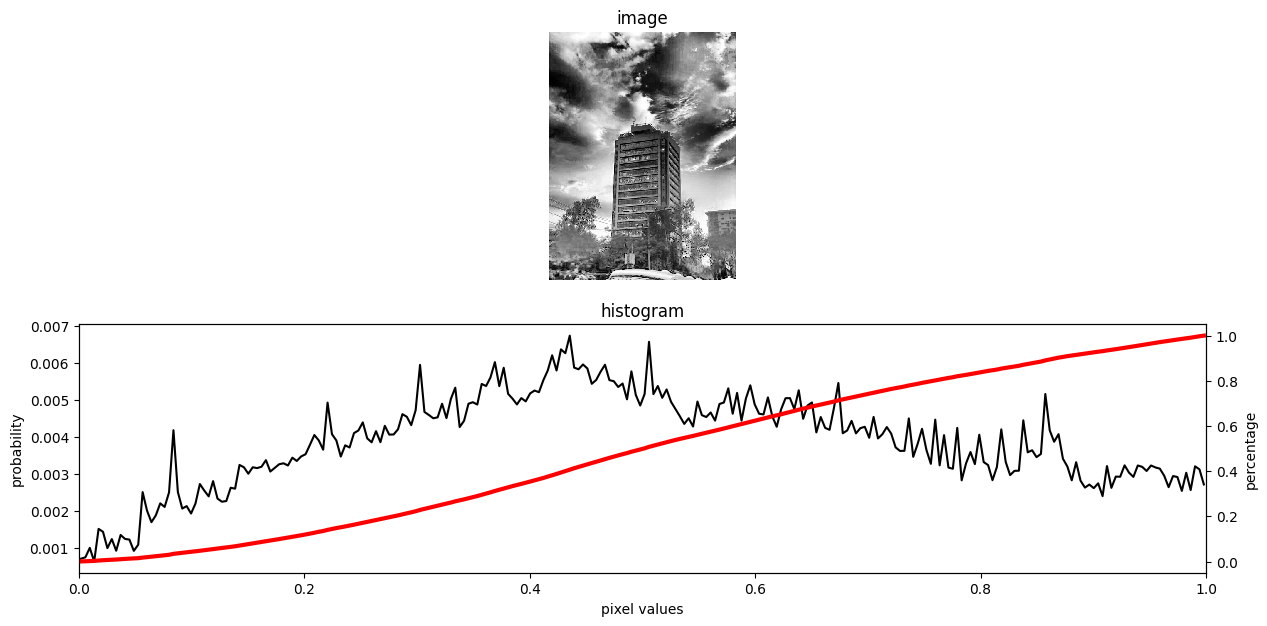

In [51]:
# Equalize the histogram of the degraded image I_degraded using AHE
# Save the result in I_recon_gray_2
I_recon_gray_2 = exposure.equalize_adapthist(I_degraded, kernel_size=(128, 128), clip_limit=0)

### Write a code to display the I_recon_gray_2 along with its histogram + CDF -

def plot_img_and_hist(I, nbins=256, normalize=False, plot_cdf=True, figsize=(12, 6)):
    fig, ax = plt.subplots(2, 1, figsize=figsize)
    plt.subplot(2, 1, 1)
    io.imshow(I)
    plt.axis("off")
    plt.title("image")

    plt.subplot(2, 1, 2)
    plot_hist(I_recon_gray_2, nbins=nbins, normalize=normalize, plot_cdf=plot_cdf)
    plt.title("histogram")

plt.rcParams['figure.figsize'] = (6, 6)
plot_img_and_hist(I_recon_gray_2, normalize=True)
plt.show()
### Code ends

/tmp/ipython-input-2902782740.py:10: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I)


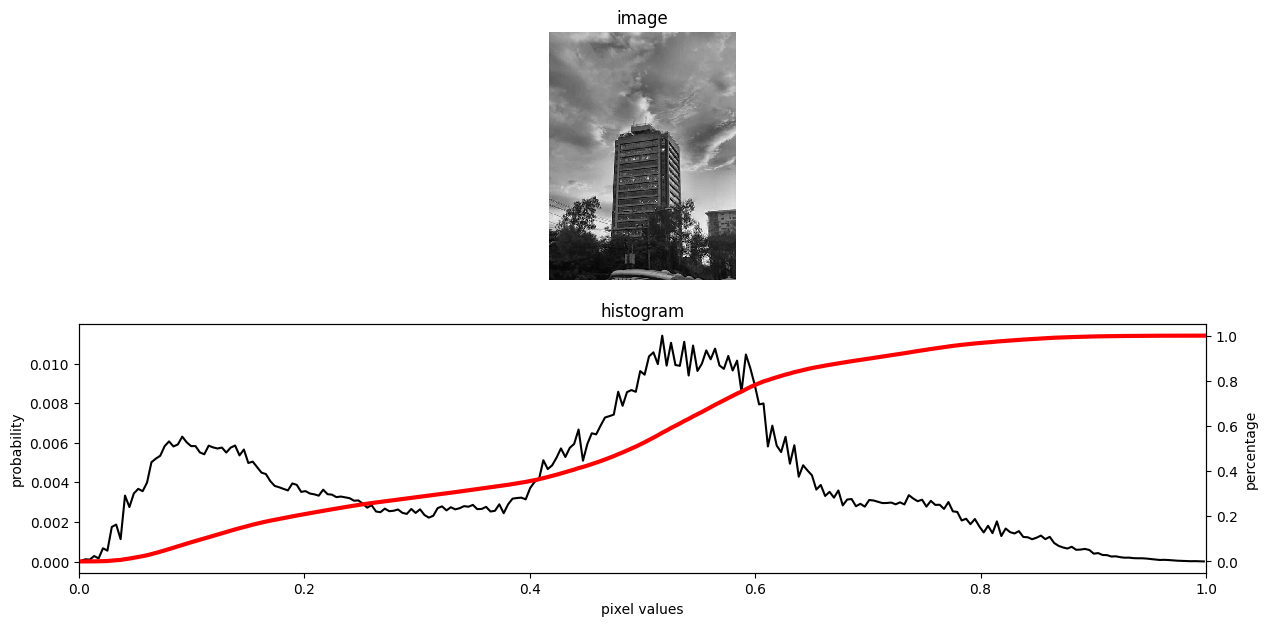

In [52]:
# Equalize the histogram of the degraded image I_degraded using CLAHE
# Save the result in I_recon_gray_3
I_recon_gray_3 = exposure.equalize_adapthist(I_degraded, kernel_size=(64, 64), clip_limit=0.01)

### Write a code to display the I_recon_gray_3 along with its histogram + CDF -

def plot_img_and_hist(I, nbins=256, normalize=False, plot_cdf=True, figsize=(12, 6)):
    fig, ax = plt.subplots(2, 1, figsize=figsize)
    plt.subplot(2, 1, 1)
    io.imshow(I)
    plt.axis("off")
    plt.title("image")

    plt.subplot(2, 1, 2)
    plot_hist(I_recon_gray_3, nbins=nbins, normalize=normalize, plot_cdf=plot_cdf)
    plt.title("histogram")

plt.rcParams['figure.figsize'] = (6, 6)
plot_img_and_hist(I_recon_gray_3, normalize=True)
plt.show()

### Code ends

/tmp/ipython-input-3718695159.py:15: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I_rgb_degraded)


Text(0.5, 1.0, 'Degraded RGB Image with Reduced Contrast')

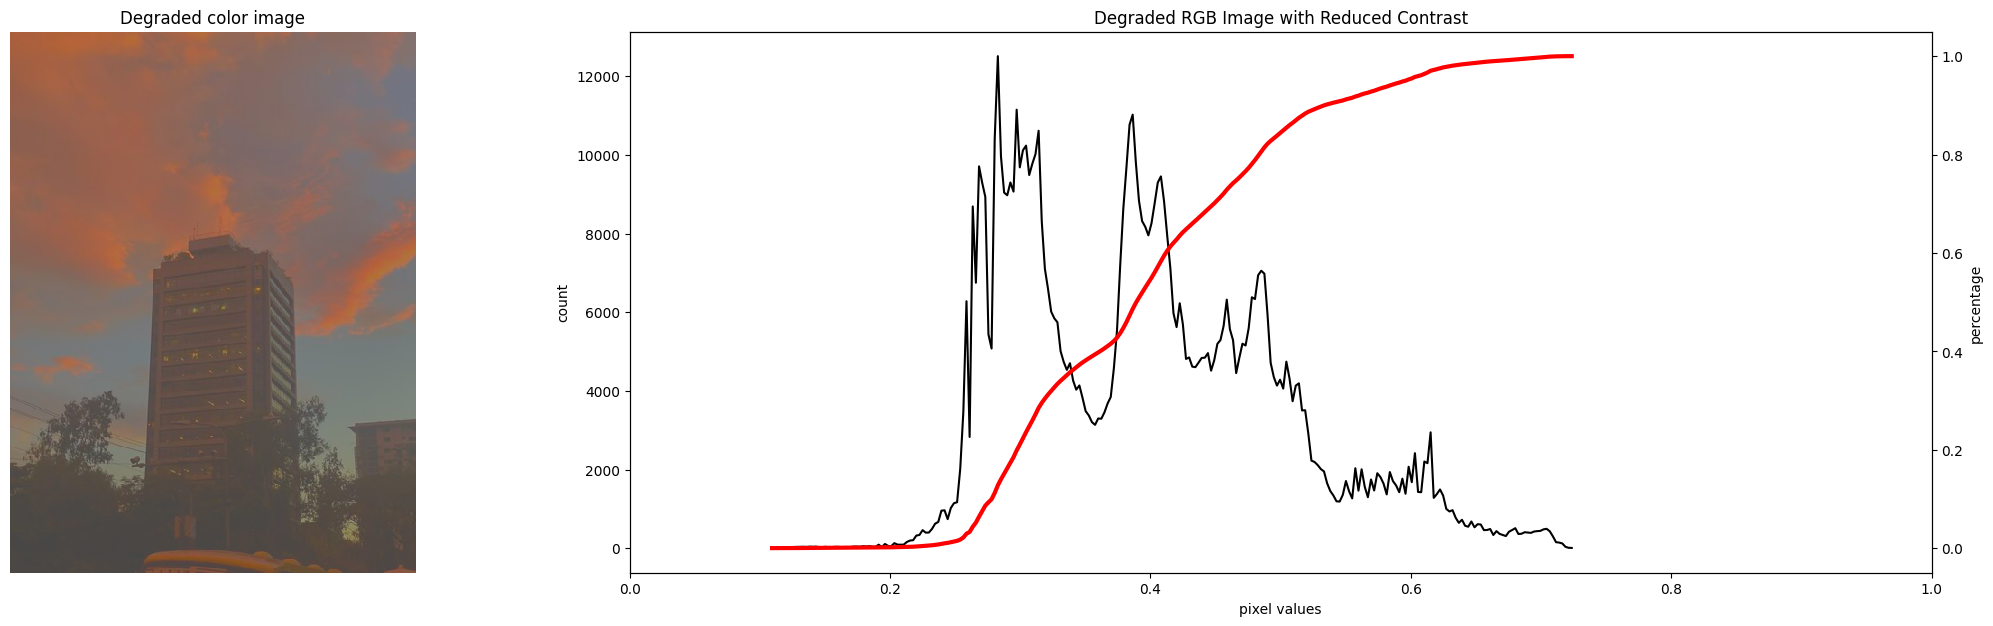

In [56]:
# Artificially degrade the original **RGB image** by reducing it contrast
# You can do so by recaling the values of the L channel (in LAB color space)
# and concentrating them in a narrow range, say between 0.3 and 0.6.
# Save the image as I_rgb_degraded and display it
Ilab = color.rgb2lab(I)
Ilab[:, :, 0] = Ilab[:, :, 0]/100
I_rgb_degraded = exposure.rescale_intensity(Ilab[:, :, 0], in_range=(0, 1), out_range=(0.3, 0.6))
Ilab[:, :, 0] = I_rgb_degraded*100
I_rgb_degraded=color.lab2rgb(Ilab)


### BEGIN SOLUTION
plt.rcParams['figure.figsize'] = (24, 6)
plt.subplot(1, 2, 1)
io.imshow(I_rgb_degraded)
plt.axis('off')
plt.title("Degraded color image")

plt.subplot(1, 2, 2)
plot_hist(I_rgb_degraded, plot_cdf=True)
plt.title("Degraded RGB Image with Reduced Contrast")

### END SOLUTION

/tmp/ipython-input-2247590615.py:19: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I_recon_color)


Text(0.5, 1.0, 'Histogram')

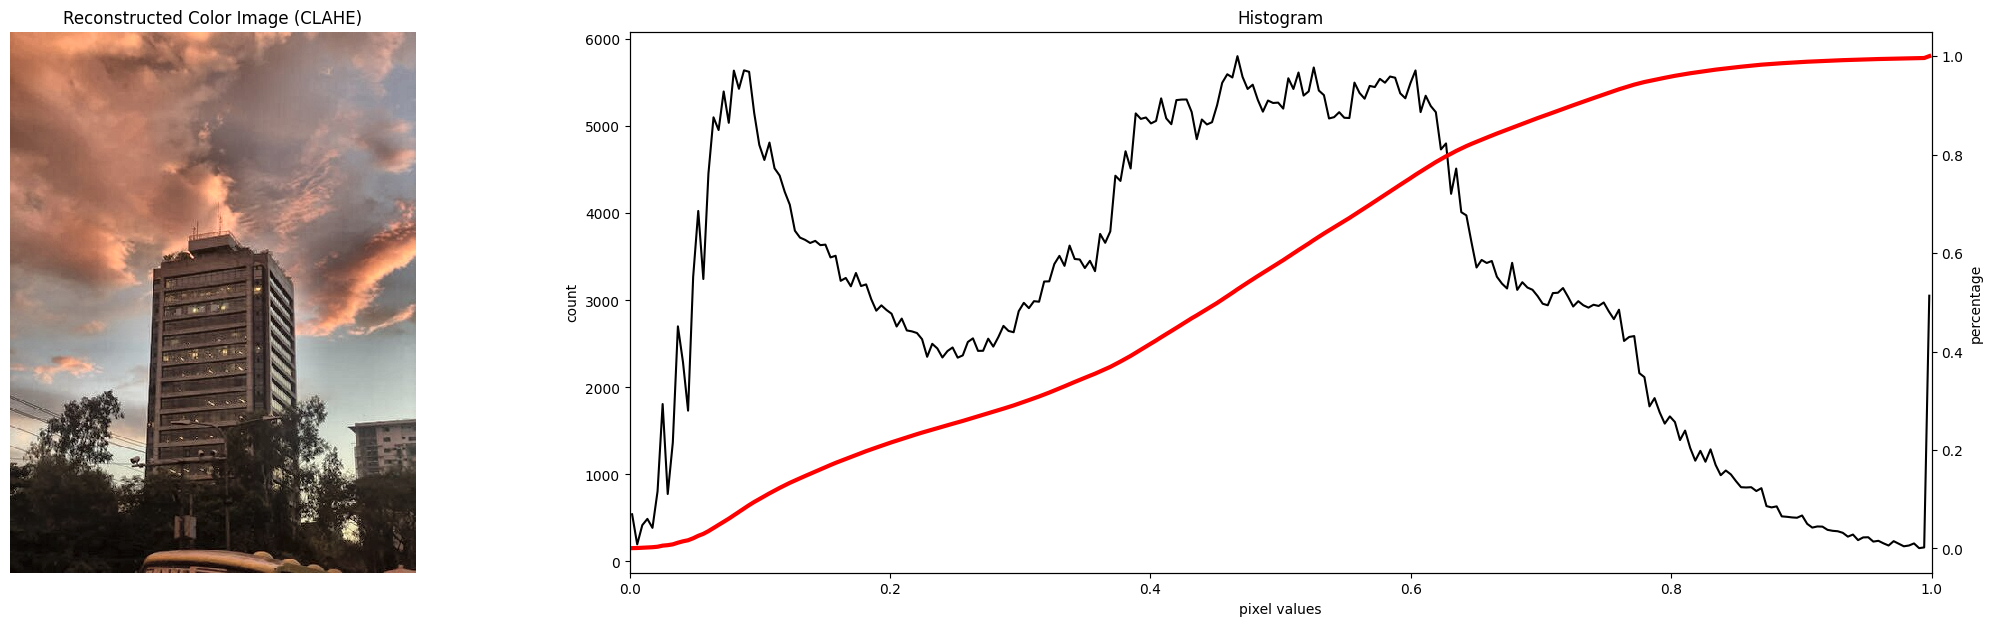

In [57]:
# Equalize the histogram of the degraded color image I_rgb_degraded using CLAHE
# Save the result in I_recon_color, display the image along with its histogram
# HINT: You have to convert to LAB first
# See the lecture and lecture-4-demo-codes

Ilab = color.rgb2lab(I_rgb_degraded)
Ilab[:, :, 0] = Ilab[:, :, 0]/100
#plot_img_and_hist(Ilab[:, :, 0])
I_eq = exposure.equalize_adapthist(Ilab[:, :, 0], kernel_size=(64, 64), clip_limit=0.01)
Ilab[:, :, 0] = I_eq*100
I_recon_color = color.lab2rgb(Ilab)




### BEGIN SOLUTION
plt.rcParams['figure.figsize'] = (24,6)
plt.subplot(1, 2, 1)
io.imshow(I_recon_color)
plt.axis('off')
plt.title("Reconstructed Color Image (CLAHE)")

plt.subplot(1, 2, 2)
plot_hist(I_recon_color, plot_cdf=True)
plt.title("Histogram")
### END SOLUTION

## Task 3 - Recovering QR code

You have been provided a badly damaged QR code - https://drive.google.com/file/d/1e_ESpQ88tYx01mwVCC2O2hCvRwsPu3KN/view?usp=sharing

Your task is to recover it. Apply global histogram equalization, AHE and CLAHE on the image and see if you can read any version of the image.

❗For AHE and CLAHE, do not use a kernel size greater than 64.❗

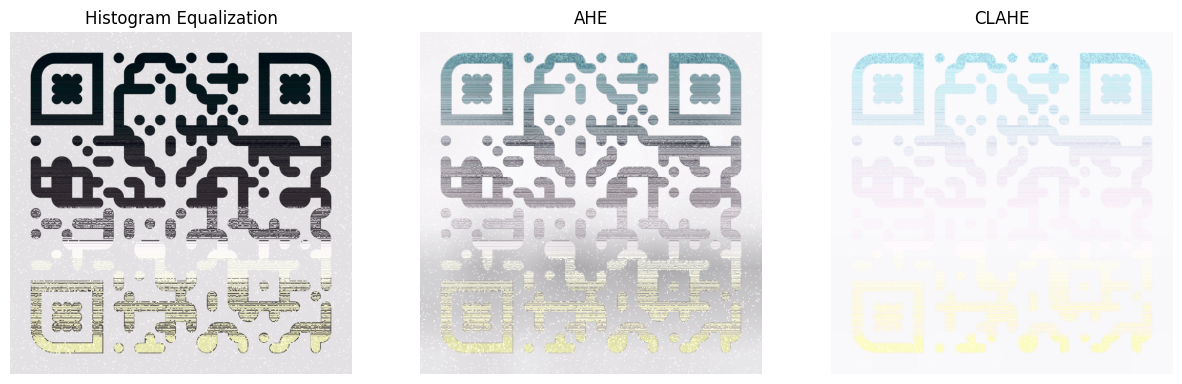

In [62]:
# Download the image from the drive link above
# Upload it to your current working directory in colab
# Load the image and save it under I variable
I = io.imread("QR_code.png")

# Convert to LAB
I_lab = cv2.cvtColor(I, cv2.COLOR_BGR2LAB)
L, A, B = cv2.split(I_lab)

# Apply the processing methods -
# 1. Histogram Equalization on L-channel
L_histeq = cv2.equalizeHist(L)
I_histeq = cv2.merge([L_histeq, A, B])
I_histeq = cv2.cvtColor(I_histeq, cv2.COLOR_LAB2BGR)

# 2. Adaptive Histogram Equalization (AHE)
ahe = cv2.createCLAHE(clipLimit=40.0, tileGridSize=(8,8))
L_ahe = ahe.apply(L)
I_ahe = cv2.merge([L_ahe, A, B])
I_ahe = cv2.cvtColor(I_ahe, cv2.COLOR_LAB2BGR)

# 3. CLAHE (Contrast Limited AHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
L_clahe = clahe.apply(L)
I_clahe = cv2.merge([L_clahe, A, B])
I_clahe = cv2.cvtColor(I_clahe, cv2.COLOR_LAB2BGR)

### Display the processed images on a 1x3 subplot
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Histogram Equalization")
plt.imshow(cv2.cvtColor(I_histeq, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,3,2)
plt.title("AHE")
plt.imshow(cv2.cvtColor(I_ahe, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,3,3)
plt.title("CLAHE")
plt.imshow(cv2.cvtColor(I_clahe, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()

### Code ends

**Q1. Enter the link embedded in the QR code (if needed do a separate plot of each processed image) -**

*Answer -* None worked for me

**Q2. Which method(s) worked for you?**

*Answer -* None of the three (Histogram Equalization, AHE, CLAHE) worked for me.

**Q3. Why do you think the method(s) worked? Or why did the other method(s) fail to work?**

*Answer -* All three methods failed because they: Distorted the contrast uniformity, Modified the shape of the QR modules, Increased or smoothed noise

# **Part 2 [15 Marks]**

In this part of the assignment, you will work with filters.

In [6]:
import time
from scipy import signal
### If you need other dependencies import here -
from scipy.signal import correlate2d, convolve2d
from skimage import io
### Code ends

In [ ]:
### If you need helper functions defined, define here -

### Code ends

## Task 1 - Correlation vs Convolution

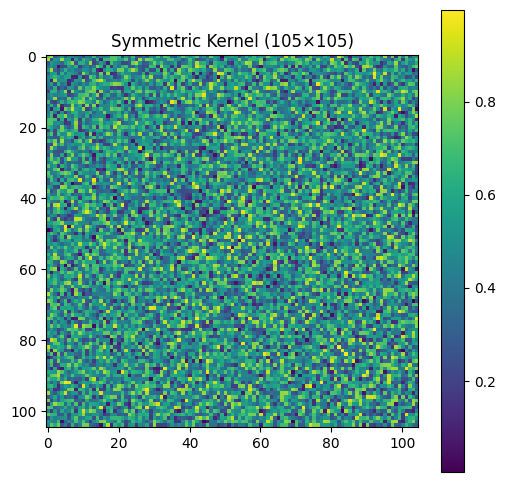

In [7]:
# Define any symmetric kernel of size (105, 105)
k = np.random.rand(105, 105)
kernel_symmetric = (k + k.T) / 2

### Write a code to display the kernel -
plt.figure(figsize=(6,6))
plt.imshow(kernel_symmetric, cmap='viridis')
plt.colorbar()
plt.title("Symmetric Kernel (105×105)")
plt.show()
### Code ends

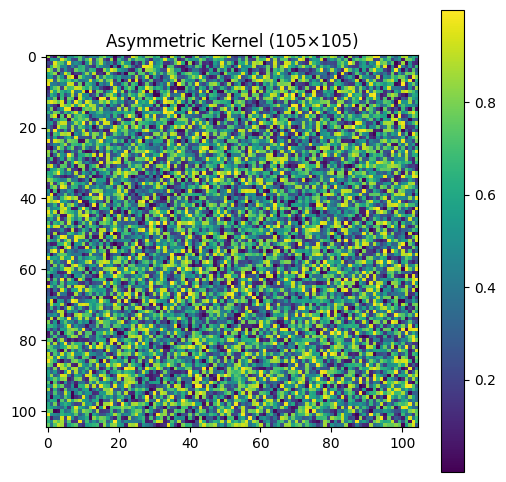

In [8]:
# Define any asymmetric kernel of size (105, 105)
kernel_asymmetric = np.random.rand(105, 105)  # example asymmetric kernel

### Write a code to display the kernel -

plt.figure(figsize=(6,6))
plt.imshow(kernel_asymmetric, cmap='viridis')
plt.colorbar()
plt.title("Asymmetric Kernel (105×105)")
plt.show()

### Code ends


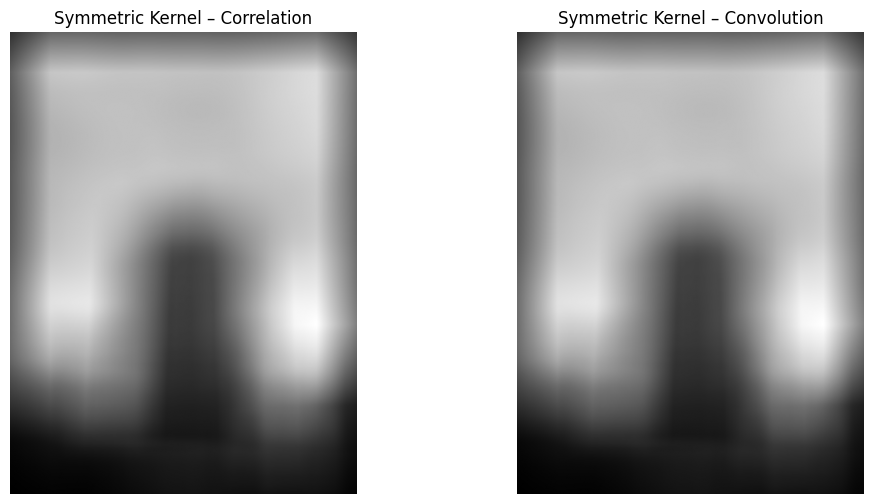

In [12]:
# Filter the image with the symmetric kernel

# Filter using correlation
I= io.imread("sample_1.jpg")
I_gray = I.mean(axis=2)   # simple average method
filtered_image_symmetric_corr = correlate2d(I_gray, kernel_symmetric, mode='same')

# Filter using convolution
filtered_image_symmetric_conv = convolve2d(I_gray, kernel_symmetric, mode='same')

### Write a code to display the symmetric filtered images side by side in a subplot -
plt.figure(figsize=(12,6))

plt.subplot(1, 2, 1)
plt.imshow(filtered_image_symmetric_corr, cmap='gray')
plt.title("Symmetric Kernel – Correlation")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(filtered_image_symmetric_conv, cmap='gray')
plt.title("Symmetric Kernel – Convolution")
plt.axis("off")

plt.show()
### Code ends

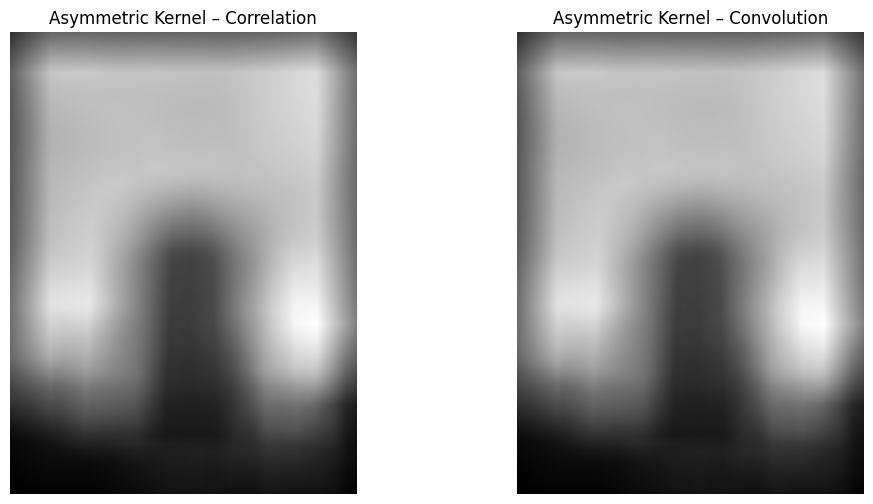

In [11]:
# Filter the image with the asymmetric kernel

# Filter using correlation
I_gray = I.mean(axis=2)
filtered_image_asymmetric_corr = correlate2d(I_gray, kernel_asymmetric, mode='same')
# Filter using convolution
filtered_image_asymmetric_conv = convolve2d(I_gray, kernel_asymmetric, mode='same')

### Write a code to display the asymmetric filtered images side by side in a subplot -
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(filtered_image_asymmetric_corr, cmap='gray')
plt.title("Asymmetric Kernel – Correlation")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(filtered_image_asymmetric_conv, cmap='gray')
plt.title("Asymmetric Kernel – Convolution")
plt.axis("off")

plt.show()

### Code ends

**Q1. Are the outputs for correlation and convolution same?**

*Answer -* Yes

**Q2. Provide reasoning -**

*Answer -* he large size of the kernel and the averaging effect make both symmetric and asymmetric kernels produce very similar outputs, so you see the same result even when the kernels are different.

## Task 2 - Finding edges

Load this image - https://drive.google.com/file/d/1MxHHPoXv0jg6SG3tKIWLAsfMncC662F6/view?usp=sharing

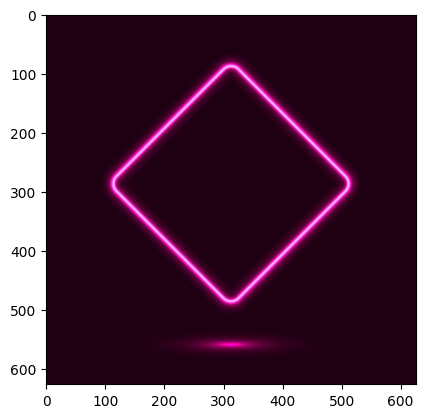

In [18]:
# Download the image from the drive link above
# Upload it to your current working directory in colab
# Load the image and save it under I variable
I = io.imread("Diamond.jpg")

### Write a code to display the image -
plt.imshow(I)

plt.show()
### Code ends

The diamond in the image has two parallel sides. You will need to come up with two $3\times3$ kernels to detect the two sets of parallel sides. Your filters should not detect all the four sides at once.

In [21]:
# Define the 2 custom kernels by replacing the "?"s with your values
# After finding out the values, uncomment the next few lines of code in this cell

kernel_1 = np.array([[ 1,  0, -1],
                     [ 1,  0, -1],
                     [ 1,  0, -1]])


kernel_2 = np.array([[ 1,  1,  1],
                     [ 0,  0,  0],
                     [-1, -1, -1]])

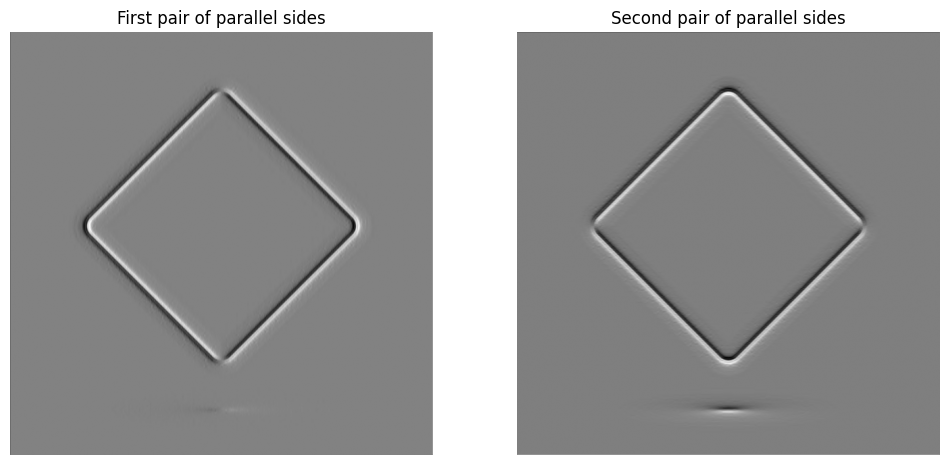

In [20]:
# Apply kernel_1 on I and save it as first_pair
I_gray = I.mean(axis=2)
first_pair = correlate2d(I_gray, kernel_1, mode='same')

# Apply kernel_2 on I and save it as second_pair
second_pair = correlate2d(I_gray, kernel_2, mode='same')

### Write a code to display the two filtered images side by side in a subplot

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(first_pair, cmap='gray')
plt.title("First pair of parallel sides")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(second_pair, cmap='gray')
plt.title("Second pair of parallel sides")
plt.axis("off")

plt.show()
### Code ends

**Q1. Which filters did you use and why?**

*Answer -* I used two custom 3×3 directional edge-detection kernels:

kernel_1 detects one pair of parallel sides.

kernel_2 detects the other pair of parallel sides.

These kernels were chosen to respond to edges along specific directions so that each set of parallel sides of the diamond is detected separately, without detecting all four sides at once.

**Q2. Are your kernels unique or there can be other kernels which can accomplish the same task?**

*Answer -* The kernels are not unique. There are many other possible 3×3 kernels or filters that can detect the same edges, as long as they emphasize intensity changes along the desired directions. Different weights, orientations, or even slightly larger kernels could accomplish the same task.